In [1]:
import geonamescache
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
def get_countries_cities():
    gc = geonamescache.GeonamesCache()
    countries = gc.get_countries()
    df_countries = pd.DataFrame(countries.values())
    cities = gc.get_cities()
    df_cities = (
        pd.DataFrame(cities.values())
        .merge(
            df_countries[["iso", "continentcode"]],
            left_on="countrycode",
            right_on="iso",
            how="left",
        )
        .drop(columns=["iso"])
    )
    return df_countries, df_cities


df_countries, df_cities = get_countries_cities()
df_countries

,geonameid,name,iso,iso3,isonumeric,fips,continentcode,capital,areakm2,population,tld,currencycode,currencyname,phone,postalcoderegex,languages,neighbours
0,3041565,Andorra,AD,AND,20,AN,EU,Andorra la Vella,468,77006,.ad,EUR,Euro,376,^(?:AD)*(\d{3})$,ca,"ES,FR"
1,290557,United Arab Emirates,AE,ARE,784,AE,AS,Abu Dhabi,82880,9630959,.ae,AED,Dirham,971,,"ar-AE,fa,en,hi,ur","SA,OM"
2,1149361,Afghanistan,AF,AFG,4,AF,AS,Kabul,647500,37172386,.af,AFN,Afghani,93,,"fa-AF,ps,uz-AF,tk","TM,CN,IR,TJ,PK,UZ"
3,3576396,Antigua and Barbuda,AG,ATG,28,AC,NA,St. John's,443,96286,.ag,XCD,Dollar,+1-268,,en-AG,
4,3573511,Anguilla,AI,AIA,660,AV,NA,The Valley,102,13254,.ai,XCD,Dollar,+1-264,,en-AI,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,953987,South Africa,ZA,ZAF,710,SF,AF,Pretoria,1219912,57779622,.za,ZAR,Rand,27,^(\d{4})$,"zu,xh,af,nso,en-ZA,tn,st,ts,ss,ve,nr","ZW,SZ,MZ,BW,NA,LS"
248,895949,Zambia,ZM,ZMB,894,ZA,AF,Lusaka,752614,17351822,.zm,ZMW,Kwacha,260,^(\d{5})$,"en-ZM,bem,loz,lun,lue,ny,toi","ZW,TZ,MZ,CD,NA,MW,AO"
249,878675,Zimbabwe,ZW,ZWE,716,ZI,AF,Harare,390580,14439018,.zw,ZWL,Dollar,263,,"en-ZW,sn,nr,nd","ZA,MZ,BW,ZM"
250,8505033,Serbia and Montenegro,CS,SCG,891,YI,EU,Belgrade,102350,10829175,.cs,RSD,Dinar,381,^(\d{5})$,"cu,hu,sq,sr","AL,HU,MK,RO,HR,BA,BG"


In [4]:
def filter_cities(df_cities, continentcode, population):
    return df_cities[
        (df_cities["continentcode"] == continentcode)
        & (df_cities["population"] > population)
    ]


df_european_cities = filter_cities(df_cities, "EU", 10_000)
df_european_cities.to_csv("european_cities.csv", index=False, sep=";")
df_european_cities.head()

,geonameid,name,latitude,longitude,countrycode,population,timezone,admin1code,alternatenames,continentcode
0,3040051,les Escaldes,42.50729,1.53414,AD,15853,Europe/Andorra,08,"[Ehskal'des-Ehndzhordani, Escaldes, Escaldes-E...",EU
1,3041563,Andorra la Vella,42.50779,1.52109,AD,20430,Europe/Andorra,07,"[ALV, Ando-la-Vyey, Andora, Andora la Vela, An...",EU
72,363243,Sarandë,39.87534,20.00477,AL,15147,Europe/Tirane,51,"[Agioi, Agioi Saranta, Ayii Saranda, Hagios Sa...",EU
73,781988,Pogradec,40.90250,20.65250,AL,61530,Europe/Tirane,46,"[Opshtina Pogradec, Podgradec, Pogradec, Pogra...",EU
74,782661,Kukës,42.07694,20.42194,AL,17832,Europe/Tirane,47,"[Cucus, KFZ, Kukes, Kukesi, Kuks, Kuksi, Kukuc...",EU


c:\Daten\ADLS\NGDS-DZP\DZP-hols\Gruppe_L\.venv\lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


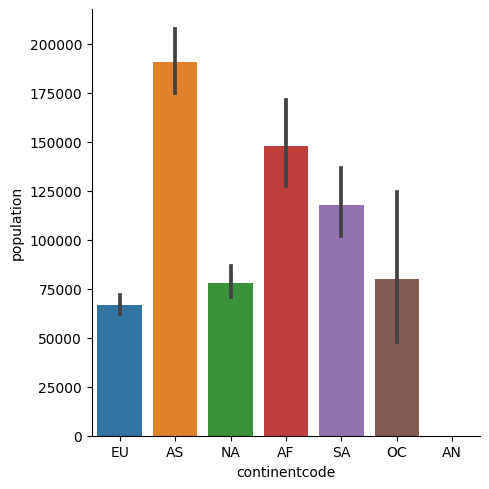

In [31]:
g = sns.catplot(
    df_cities,
    x="continentcode",
    y="population",
    kind="bar",
)


c:\Daten\ADLS\NGDS-DZP\DZP-hols\Gruppe_L\.venv\lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


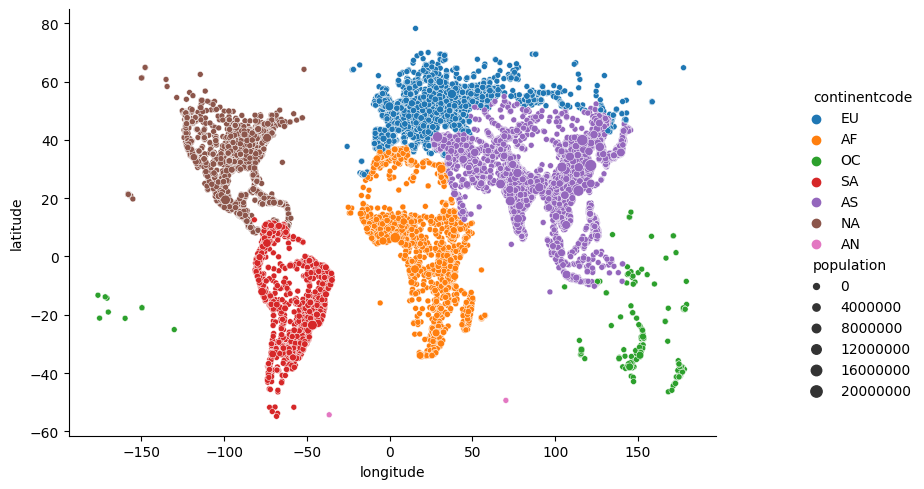

In [32]:
g = sns.relplot(
    df_cities.sort_values("population", ascending=True),
    x="longitude",
    y="latitude",
    hue="continentcode",
    size="population",
)
g.fig.set_size_inches(10, 5)
